# TensorBinding.jl — Special Hamiltonians

Hamiltonians requiring more advanced multi-layer construction:

1. **Twisted Bilayer Graphene (TBG)** — twisted multilayer with
   exponentially decaying interlayer coupling, compressed via QTCI.


---
## 1. Twisted Bilayer Graphene

`twisted_bilayer_hamiltonian(lattice, Lx, Ly, theta_deg; t_intra, t_inter, alpha_decay)`
constructs the full two-layer Hamiltonian: intra-layer NN hopping + exponentially
decaying interlayer coupling $V(r) = t_\perp e^{-\alpha|r|}$ compressed via QTCI.

At the magic angle $\theta \approx 1.05^\circ$ the low-energy bands become nearly
flat, signalling strong-correlation physics.

In [8]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
include("../src/TensorBinding.jl")
using .TensorBinding

In [22]:
# ── Parameters ────────────────────────────────────────────────────────────────
Lx    = 3          # 2^Lx sites per row
Ly    = 3          # 2^Ly rows
θ_deg = 5.0        # twist angle (degrees)

# ── Build the TBG Hamiltonian in one call ─────────────────────────────────────
H = TensorBinding.twisted_bilayer_hamiltonian(:honeycomb, Lx, Ly, θ_deg;
        t_intra = 1.0,
        t_inter = 0.3,
        α_decay = 1 / 5)

println("Sites per layer : $(2^(Lx+Ly))")
println("MPO length      : $(length(H.mpo))")
println("Max bond dim    : $(ITensorMPS.maxlinkdim(H.mpo))")

MPS COMPUTED!
Turned into MPO!
MPS COMPUTED!
Turned into MPO!
Sites per layer : 64
MPO length      : 7
Max bond dim    : 29


In [23]:
TensorBinding.truncate!(H; cutoff=1e-5)
println(H)

TBHamiltonian | L=6, N=64 +2layers, scale=auto, maxlinkdim=12 | geometry: no geometry | no Tn cache


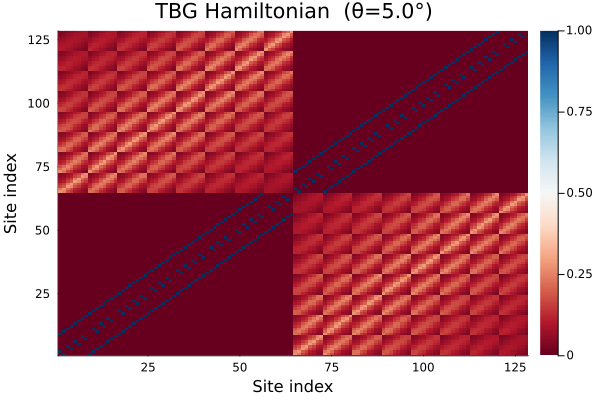

In [24]:
M = real.(TensorBinding.get_matrix(H.mpo, H.sites))

heatmap(M;
        title  = "TBG Hamiltonian  (θ=$(θ_deg)°)",
        xlabel = "Site index", ylabel = "Site index",
        color  = :RdBu, clims = (0, maximum(abs, M)))

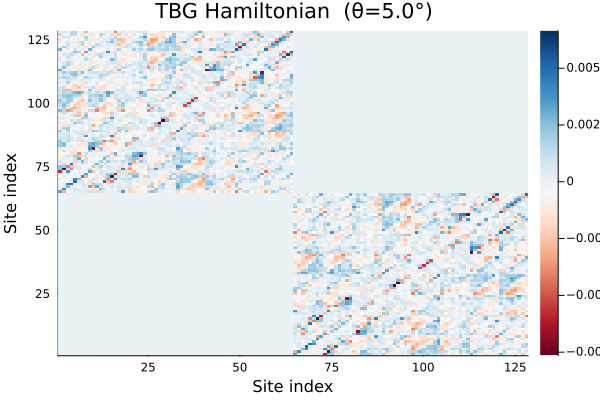

In [26]:
heatmap(M-H_dense;
        title  = "TBG Hamiltonian  (θ=$(θ_deg)°)",
        xlabel = "Site index", ylabel = "Site index",
        color  = :RdBu)

In [27]:
# ── KPM density of states ─────────────────────────────────────────────────────
Ncheb      = 100
maxdim_kpm = 100

Tn, scale, center = TensorBinding.KPM_Tn(H, Ncheb; maxdim=maxdim_kpm, cutoff=1e-5)

KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -5.4459,  E_max = 10.8598
  center = 2.7069,  scale = 8.9682
13
15
19
20
25
28
31
31
35
35
38
39
41
42
43
44
44
46
45
47
46
48
48
49
49
50
49
50
50
52
51
52
52
53
52
53
53
54
54
54
54
54
54
55
54
55
54
55
55
55
56
55
56
56
56
56
56
56
56
56
57
57
57
57
57
57
57
57
57
57
57
57
58
57
57
57
58
58
58
58
57
58
58
58
58
58
58
58
58
58
58
58
59
58
59
58
59
58
59


(MPO[MPO
[1] ((dim=2|id=326|"Layer")', (dim=2|id=326|"Layer"), (dim=1|id=547|"Link,l=1"))
[2] ((dim=2|id=869|"Qubit,Site,n=1")', (dim=2|id=869|"Qubit,Site,n=1"), (dim=1|id=246|"Link,l=2"), (dim=1|id=547|"Link,l=1"))
[3] ((dim=2|id=865|"Qubit,Site,n=2")', (dim=2|id=865|"Qubit,Site,n=2"), (dim=1|id=408|"Link,l=3"), (dim=1|id=246|"Link,l=2"))
[4] ((dim=2|id=34|"Qubit,Site,n=3")', (dim=2|id=34|"Qubit,Site,n=3"), (dim=1|id=865|"Link,l=4"), (dim=1|id=408|"Link,l=3"))
[5] ((dim=2|id=571|"Qubit,Site,n=4")', (dim=2|id=571|"Qubit,Site,n=4"), (dim=1|id=935|"Link,l=5"), (dim=1|id=865|"Link,l=4"))
[6] ((dim=2|id=942|"Qubit,Site,n=5")', (dim=2|id=942|"Qubit,Site,n=5"), (dim=1|id=732|"Link,l=6"), (dim=1|id=935|"Link,l=5"))
[7] ((dim=2|id=347|"Qubit,Site,n=6")', (dim=2|id=347|"Qubit,Site,n=6"), (dim=1|id=732|"Link,l=6"))
, MPO
[1] ((dim=2|id=326|"Layer")', (dim=2|id=326|"Layer"), (dim=4|id=721|"Link,l=0"))
[2] ((dim=2|id=869|"Qubit,Site,n=1")', (dim=2|id=869|"Qubit,Site,n=1"), (dim=10|id=677|"Link,l=1

ω = -6.26
ω = -5.9
ω = -5.53
ω = -5.16
ω = -4.8
ω = -4.43
ω = -4.06
ω = -3.7
ω = -3.33
ω = -2.97
ω = -2.6
ω = -2.23
ω = -1.87
ω = -1.5
ω = -1.14
ω = -0.771
ω = -0.404
ω = -0.0384
ω = 0.328
ω = 0.694
ω = 1.06
ω = 1.43
ω = 1.79
ω = 2.16
ω = 2.52
ω = 2.89
ω = 3.26
ω = 3.62
ω = 3.99
ω = 4.35
ω = 4.72
ω = 5.09
ω = 5.45
ω = 5.82
ω = 6.18
ω = 6.55
ω = 6.92
ω = 7.28
ω = 7.65
ω = 8.01
ω = 8.38
ω = 8.75
ω = 9.11
ω = 9.48
ω = 9.84
ω = 10.2
ω = 10.6
ω = 10.9
ω = 11.3
ω = 11.7


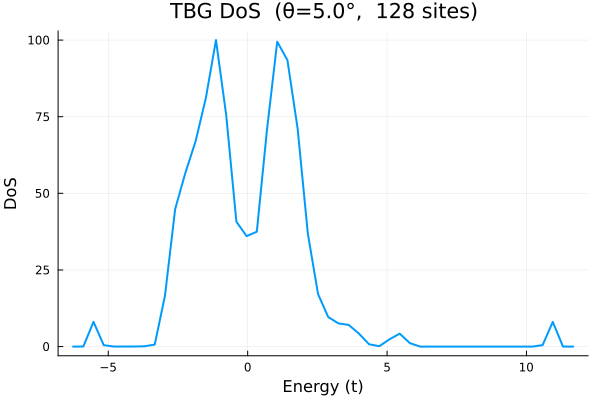

In [31]:
ω_grid = range(center - scale, center + scale; length=50)
dos = [begin
    ω_r = (ω - center) / scale
    println("ω = $(round(ω, sigdigits=3))")
    abs(ω_r) >= 1.0 ? 0.0 :
        real(tr(TensorBinding.get_ldos_w_from_Tn(Tn, Ncheb, ω_r; maxdim=maxdim_kpm)))
end for ω in ω_grid]

plot(ω_grid, dos;
     xlabel="Energy (t)", ylabel="DoS",
     title="TBG DoS  (θ=$(θ_deg)°,  $(2*2^(Lx+Ly)) sites)",
     legend=false, lw=2)

In [ ]:
# ── DoS vs twist angle ────────────────────────────────────────────────────────
θ_sweep   = range(0.0, 10.0; length=8)
ω_sweep   = range(center - scale, center + scale; length=150)
dos_sweep = Matrix{Float64}(undef, length(ω_sweep), length(θ_sweep))

for (idx, θ_d) in enumerate(θ_sweep)
    H_loc = TensorBinding.twisted_bilayer_hamiltonian(:honeycomb, Lx, Ly, θ_d;
                t_intra=1.0, t_inter=0.3, α_decay=1/1.5)
    Tn_loc, sc, cn = TensorBinding.KPM_Tn(H_loc, Ncheb;
                         maxdim=maxdim_kpm, cutoff=1e-5)
    for (iω, ω) in enumerate(ω_sweep)
        ω_r = (ω - cn) / sc
        dos_sweep[iω, idx] = abs(ω_r) >= 1.0 ? 0.0 :
            real(tr(TensorBinding.get_ldos_w_from_Tn(Tn_loc, Ncheb, ω_r; maxdim=maxdim_kpm)))
    end
    println("θ = $(round(θ_d; digits=2))° done")
end

heatmap(collect(θ_sweep), collect(ω_sweep), dos_sweep;
        xlabel="Twist angle θ (°)", ylabel="Energy (t)",
        title="TBG DoS vs twist angle",
        color=:inferno, colorbar_title="DoS")

---
## Exact diagonalization benchmark

Build the same $2N \times 2N$ Hamiltonian as a dense matrix and compare the KPM DoS against
Gaussian-broadened exact eigenvalues.

In [16]:
N   = 2^(Lx + Ly)
t   = 1.0
rs1 = TensorBinding.lattice_positions(:honeycomb, Lx, Ly; angle_deg=0.0)
rs2 = TensorBinding.lattice_positions(:honeycomb, Lx, Ly; angle_deg=θ_deg)

H_mono_dense = [abs(norm(rs1[i,:] - rs1[j,:]) - 1.0) < 1e-6 ? t : 0.0
                for i in 1:N, j in 1:N]
V_dense      = [0.3 * exp(-(1/5.) * norm(rs1[i,:] - rs2[j,:])) for i in 1:N, j in 1:N]
H_dense      = [H_mono_dense  V_dense; V_dense'  H_mono_dense]

println("Hermitian: $(ishermitian(H_dense))")
println("NN bonds per site: $(round(sum(H_mono_dense .!= 0) / N; digits=2))")

Hermitian: true
NN bonds per site: 2.62


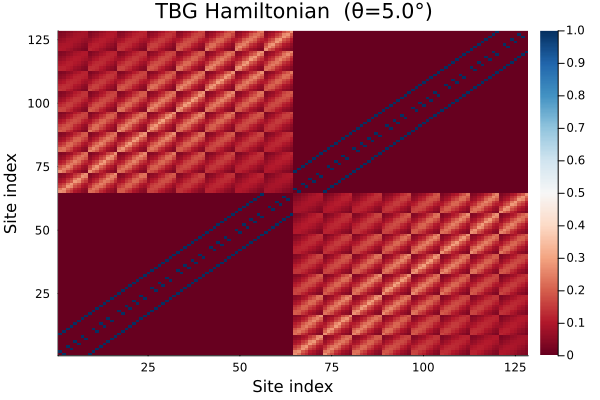

In [17]:
heatmap(H_dense; title  = "TBG Hamiltonian  (θ=$(θ_deg)°)",
        xlabel = "Site index", ylabel = "Site index",
        color  = :RdBu, clims = (0, maximum(abs, H_dense)))

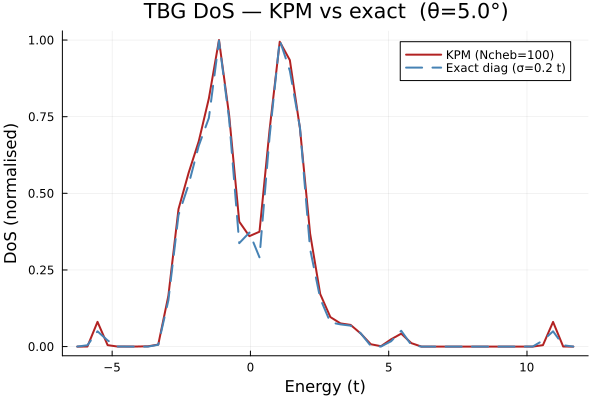

In [34]:
σ_broad  = 0.2
ε_exact  = eigvals(Hermitian(H_dense))
dos_exact = [sum(@. exp(-(ω - ε_exact)^2 / (2σ_broad^2)) / (sqrt(2π) * σ_broad))
             for ω in ω_grid] ./ (2N)

dos_kpm_norm   = dos      ./ maximum(dos)
dos_exact_norm = dos_exact ./ maximum(dos_exact)

plot(ω_grid, dos_kpm_norm;
     label="KPM (Ncheb=$(Ncheb))", lw=2, color=:firebrick,
     xlabel="Energy (t)", ylabel="DoS (normalised)",
     title="TBG DoS — KPM vs exact  (θ=$(θ_deg)°)")
plot!(ω_grid, dos_exact_norm;
      label="Exact diag (σ=$(σ_broad) t)", lw=2, ls=:dash, color=:steelblue)